In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *

In [18]:
input_filename = 'Grid/grid_64x64.csv'

In [19]:
def GetSolutionDict(input_filename):
    # Read the first three lines to extract grid sizes
    with open(input_filename, 'r') as f:
        ndim = int(f.readline().strip().split('=')[1])
        ni = int(f.readline().strip().split('=')[1])
        nj = int(f.readline().strip().split('=')[1])
        nk = int(f.readline().strip().split('=')[1])
    
    df = pd.read_csv(input_filename, skiprows=4)
    data_dict = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    return data_dict

    
data_dict = GetSolutionDict(input_filename)

In [20]:
data_dict.keys()

dict_keys(['x', 'y', 'z'])

In [21]:
data_dict['ax'] = data_dict['x'][:,:,0]
data_dict['r'] = np.sqrt(data_dict['y'][:,:,0]**2 + data_dict['z'][:,:,0]**2)

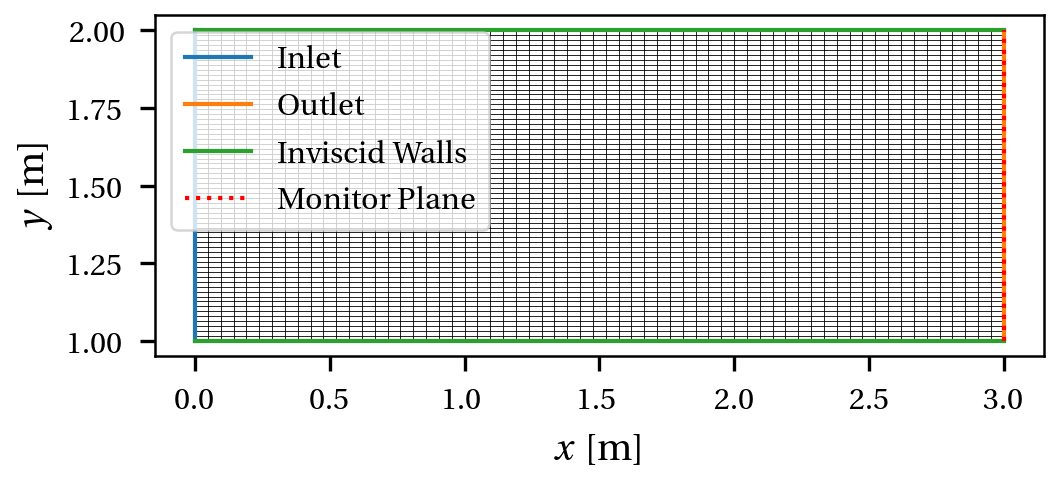

In [ ]:
ni,nj = data_dict['ax'].shape
set_thesis_style()
fig, ax = create_figure(fraction=0.7, aspect_ratio=2.2, subplots=(1, 1))
skip = 1
for i in range(0, ni, skip):
    ax.plot(data_dict['ax'][i,:], data_dict['r'][i,:], 'k-', linewidth=0.2)
for j in range(0, nj, skip):
    ax.plot(data_dict['ax'][:,j], data_dict['r'][:,j], 'k-', linewidth=0.2)

ax.plot(data_dict['ax'][0,:], data_dict['r'][0,:], 'C0-', label='Inlet')
ax.plot(data_dict['ax'][-1,:], data_dict['r'][-1,:], 'C1-', label='Outlet')
ax.plot(data_dict['ax'][:,0], data_dict['r'][:,0], 'C2-', label='Inviscid Walls')
ax.plot(data_dict['ax'][:,-1], data_dict['r'][:,-1], 'C2-')
ax.plot(data_dict['ax'][-1,:], data_dict['r'][-1,:], 'r:', label='Monitor Plane')



ax.legend()
ax.set_xlabel(r'$x$ [m]')
ax.set_ylabel(r'$y$ [m]')
fig.savefig('swirling_flow_grid.pdf')